# Pilot Methodology: System GMM, IV, and Mediation Analysis
**For Inequality-Democracy Research**

---

## Overview

This notebook demonstrates advanced econometric methods for studying how inequality, education, and democratic quality co-evolve.

### Methods

1. **System GMM with Collapsed Instruments** - Addresses instrument proliferation
2. **IV Estimation with Historical Instruments** - Uses land inequality, settler mortality, latitude
3. **Mediation Analysis with Panel Bootstrap** - Cluster bootstrap for valid SEs
4. **Specification Curve Analysis** - Tests robustness across specifications

### WARNING: PILOT DATA

**This is a PILOT using SYNTHETIC data.** Results are illustrative only, not for publication.


In [1]:
# Install dependencies (Colab-compatible pattern)
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab
_pip('loguru')
_pip('linearmodels')
_pip('joblib')
_pip('tqdm')

# Core packages (pre-installed on Colab, install locally to match)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0', 'seaborn==0.13.2', 'statsmodels==0.14.6')

print("Dependencies installed.")




[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


Dependencies installed.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Imports
from loguru import logger
import sys, json, warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import statsmodels.api as sm
from linearmodels.panel import PooledOLS
from linearmodels.iv import IV2SLS
warnings.filterwarnings('ignore')

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# Custom JSON encoder for numpy types
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.bool_): return bool(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

print("Imports complete.")



Imports complete.


## Data Loading

This cell defines the data loading helper that fetches data from GitHub (for Colab) with local fallback.


In [3]:
# Data loading helper (GitHub URL with local fallback)
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-de87a0-welfare-state-capacity-as-a-conditioning/main/round-2/experiment-1/demo/mini_demo_data.json"

import json, os

def load_data():
    """Load data from GitHub URL (for Colab) or local file."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

print("Data loading helper defined.")



Data loading helper defined.


## Load and Explore Data

Loading the mini demo dataset.


In [4]:
# Load data
data = load_data()
print(f"Data loaded. Keys: {list(data.keys())}")

if 'datasets' in data and len(data['datasets']) > 0:
    dataset = data['datasets'][0]
    print(f"Dataset: {dataset.get('dataset', 'N/A')}")
    print(f"Examples: {len(dataset.get('examples', []))}")



Data loaded. Keys: ['datasets']
Dataset: welfare_democracy_panel
Examples: 30


## Configuration

Set tunable parameters for the analysis. For the demo, we use MINIMUM values.

- `N_BOOTSTRAP`: Bootstrap repetitions (default: 100 for pilot, 1000+ for full)
- `N_SPECS_TARGET`: Number of specifications for specification curve (default: 50 for pilot, 324 for full)


In [5]:
# Configuration
N_BOOTSTRAP = 10  # Bootstrap repetitions
N_SPECS_TARGET = 8  # Specification curve specs

print(f"Config: N_BOOTSTRAP={N_BOOTSTRAP}, N_SPECS_TARGET={N_SPECS_TARGET}")



Config: N_BOOTSTRAP=10, N_SPECS_TARGET=8


## Data Preparation Function

This function loads and prepares the panel data for analysis:
- Parses input JSON from the dataset
- Adds synthetic variables for methodology demonstration
- Constructs historical instruments for IV estimation
- Sets multi-index (country_code, year) for panel analysis


In [6]:
def load_and_prepare_data(data):
    """Load and prepare panel data for analysis."""
    logger.info("Loading and preparing data...")
    examples = []
    for dataset in data.get('datasets', []):
        for example in dataset.get('examples', []):
            input_data = json.loads(example['input'])
            input_data['dem_resilience'] = float(example['output'])
            examples.append(input_data)
    df = pd.DataFrame(examples)
    logger.info(f"Loaded {len(df)} observations")
    
    # Add synthetic variables
    np.random.seed(42)
    if 'vdem_polyarchy' not in df.columns:
        df['vdem_polyarchy'] = df['dem_resilience'] + np.random.normal(0, 0.05, len(df))
        df['vdem_polyarchy'] = df['vdem_polyarchy'].clip(0, 1)
    if 'secondary_enrollment' not in df.columns:
        df['secondary_enrollment'] = (100 - df['gini'] + np.random.normal(0, 5, len(df))).clip(0, 100)
    if 'welfare_capacity_index' not in df.columns:
        df['social_spending_gdp'] = np.random.uniform(5, 25, len(df))
        df['social_protection_coverage'] = np.random.uniform(20, 90, len(df))
        df['welfare_capacity_index'] = 0.5 * (df['social_spending_gdp'] / df['social_spending_gdp'].max()) + 0.5 * (df['social_protection_coverage'] / 100)
    if 'educational_polarization' not in df.columns:
        df['educational_polarization'] = ((df['gini'] / 100) * (1 - df['secondary_enrollment'] / 100) + np.random.normal(0, 0.05, len(df))).clip(0, 1)
    
    # Historical instruments
    logger.info("Constructing historical instruments...")
    countries = df['country_code'].unique()
    for country in countries:
        country_mask = df['country_code'] == country
        df.loc[country_mask, 'land_ineq_1960'] = np.random.uniform(30, 60)
        df.loc[country_mask, 'settler_mortality_log'] = np.log(np.random.exponential(1) * 100 + 1)
        df.loc[country_mask, 'abs_latitude'] = np.random.uniform(10, 50)
    
    df['year'] = df['year'].astype(int)
    df = df.set_index(['country_code', 'year']).sort_index()
    logger.info(f"Data preparation complete. Shape: {df.shape}")
    return df

print("load_and_prepare_data function defined.")



load_and_prepare_data function defined.


## Run Data Preparation

Execute the data preparation function to create the panel DataFrame.


In [7]:
# Prepare data
df = load_and_prepare_data(data)

print("\n" + "="*60)
print("DATA SUMMARY")
print("="*60)
print(f"Number of countries: {len(df.index.get_level_values(0).unique())}")
print(f"Number of observations: {len(df)}")
print(f"Years: {df.index.get_level_values(1).min()} - {df.index.get_level_values(1).max()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())



00:26:09|INFO   |Loading and preparing data...


00:26:09|INFO   |Loaded 30 observations


00:26:09|INFO   |Constructing historical instruments...


00:26:09|INFO   |Data preparation complete. Shape: (30, 17)



DATA SUMMARY
Number of countries: 3
Number of observations: 30
Years: 1990 - 2023

Columns: ['country_name', 'gini', 'vdem_polyarchy', 'polity_iv', 'primary_enrollment', 'secondary_enrollment', 'tertiary_enrollment', 'social_spending_gdp', 'social_protection_coverage', 'welfare_capacity_index', 'educational_polarization', 'post_1990_democratizer', 'transition_year', 'dem_resilience', 'land_ineq_1960', 'settler_mortality_log', 'abs_latitude']

First few rows:
                  country_name  gini  vdem_polyarchy  polity_iv  \
country_code year                                                 
ALB          1990      Albania  46.0           0.193       -4.4   
             1991      Albania  44.2           0.327       -3.5   
             1992      Albania  43.2           0.366       -3.4   
             1993      Albania  44.2           0.406       -3.2   
             1994      Albania  45.4           0.397       -0.7   

                   primary_enrollment  secondary_enrollment  \
cou

## Method 1: System GMM with Collapsed Instruments

This method addresses instrument proliferation following Acemoglu et al. (2008):
- **Standard approach**: Uses L.gini, L2.gini, L3.gini... as instruments (many instruments)
- **Collapsed approach**: Uses ONLY L2.gini as instrument (reduces instrument count)

For this pilot, we demonstrate with:
1. Pooled OLS baseline
2. IV with collapsed instrument (L2_gini only)


In [8]:
# System GMM with Collapsed Instruments (Pilot Demonstration)
def system_gmm_collapsed(df, dependent_var='dem_resilience', 
                         independent_vars=None, mediator_var='educational_polarization'):
    """Pilot demonstration of System GMM with collapsed instruments."""
    logger.info("Running System GMM with Collapsed Instruments...")
    if independent_vars is None:
        independent_vars = ['gini']
    results = {'method': 'System GMM (Pilot)', 'specifications': {}, 'diagnostics': {}}
    
    # Create lagged variables
    df_gmm = df.copy()
    for var in [dependent_var] + independent_vars + [mediator_var]:
        df_gmm[f'L1_{var}'] = df_gmm.groupby(level=0)[var].shift(1)
        df_gmm[f'L2_{var}'] = df_gmm.groupby(level=0)[var].shift(2)
    
    # Specification 1: Pooled OLS baseline
    logger.info("\nEstimating Pooled OLS baseline...")
    try:
        y = df_gmm[dependent_var]
        X = pd.DataFrame(index=df_gmm.index)
        X['L1_gini'] = df_gmm['L1_gini']
        valid_idx = ~(y.isna() | X['L1_gini'].isna())
        y_valid = y[valid_idx]
        X_valid = X[valid_idx]
        model = PooledOLS(y_valid, X_valid)
        res = model.fit(cov_type='robust')
        results['specifications']['pooled_ols'] = {
            'formula': f"{dependent_var} ~ L1_gini",
            'coefficients': {k: float(v) for k, v in res.params.items()},
            'std_errors': {k: float(v) for k, v in res.std_errors.items()},
            'pvalues': {k: float(v) for k, v in res.pvalues.items()},
            'r_squared': float(res.rsquared),
            'n_obs': int(res.nobs)
        }
        logger.info(f"Pooled OLS R-squared: {res.rsquared:.4f}")
    except Exception as e:
        logger.error(f"Pooled OLS failed: {e}")
        results['specifications']['pooled_ols'] = {'error': str(e)}
    
    # Specification 2: IV with collapsed instrument
    logger.info("\nEstimating IV with collapsed instrument...")
    try:
        df_iv = df_gmm.dropna(subset=[dependent_var, 'gini', 'L2_gini'])
        y_iv = df_iv[dependent_var]
        Z_iv = pd.DataFrame(index=df_iv.index)
        Z_iv['constant'] = 1
        Z_iv['gini_collapsed_iv'] = df_iv['L2_gini']
        first_stage = sm.OLS(df_iv['gini'], Z_iv).fit()
        f_stat = first_stage.fvalue if hasattr(first_stage, 'fvalue') else 0
        logger.info(f"First-stage F-statistic: {f_stat:.2f}")
        gini_hat = first_stage.predict(Z_iv)
        X_iv = pd.DataFrame(index=df_iv.index)
        X_iv['constant'] = 1
        X_iv['mediator'] = df_iv[mediator_var]
        X_iv['gini_hat'] = gini_hat
        second_stage = sm.OLS(y_iv, X_iv).fit()
        results['specifications']['iv_collapsed'] = {
            'method': 'IV with collapsed instrument (L2_gini only)',
            'first_stage_f_stat': float(f_stat),
            'coefficients': {k: float(v) for k, v in second_stage.params.items()},
            'std_errors': {k: float(v) for k, v in zip(second_stage.params.index, second_stage.bse)},
            'n_obs': int(len(y_iv))
        }
        logger.info(f"IV coefficient on gini: {second_stage.params.get('gini_hat', 'N/A')}")
    except Exception as e:
        logger.error(f"IV estimation failed: {e}")
        results['specifications']['iv_collapsed'] = {'error': str(e)}
    return results

# Run System GMM
system_gmm_results = system_gmm_collapsed(df)
print("\nSystem GMM Results:")
print(json.dumps(system_gmm_results, indent=2, cls=NpEncoder))



00:26:09|INFO   |Running System GMM with Collapsed Instruments...


00:26:09|INFO   |
Estimating Pooled OLS baseline...


00:26:09|INFO   |Pooled OLS R-squared: 0.8546


00:26:09|INFO   |
Estimating IV with collapsed instrument...


00:26:09|INFO   |First-stage F-statistic: 114.39


00:26:09|INFO   |IV coefficient on gini: -0.0005792766616670806



System GMM Results:
{
  "method": "System GMM (Pilot)",
  "specifications": {
    "pooled_ols": {
      "formula": "dem_resilience ~ L1_gini",
      "coefficients": {
        "L1_gini": 0.018260760056820424
      },
      "std_errors": {
        "L1_gini": 0.0014810835920366044
      },
      "pvalues": {
        "L1_gini": 2.2948309919001986e-12
      },
      "r_squared": 0.8546121168599591,
      "n_obs": 27
    },
    "iv_collapsed": {
      "method": "IV with collapsed instrument (L2_gini only)",
      "first_stage_f_stat": 114.39140824559809,
      "coefficients": {
        "constant": 0.9841880748948775,
        "mediator": -0.44683235767388796,
        "gini_hat": -0.0005792766616670806
      },
      "std_errors": {
        "constant": 0.4396520617199971,
        "mediator": 0.7011887510629449,
        "gini_hat": 0.006638659615419384
      },
      "n_obs": 24
    }
  },
  "diagnostics": {}
}


## Method 2: IV Estimation with Historical Instruments

This method uses historical instruments to address endogeneity:
- **land_ineq_1960**: Historical land inequality
- **settler_mortality_log**: Historical settler mortality
- **abs_latitude**: Absolute latitude

We implement manual 2SLS and report first-stage F-statistics.


In [9]:
# IV Estimation with Historical Instruments
def iv_estimation_historical(df, dependent_var='dem_resilience',
                            endogenous_var='gini', mediator_var='educational_polarization',
                            historical_instruments=None):
    """IV estimation using historical instruments."""
    logger.info("Running IV Estimation with Historical Instruments...")
    if historical_instruments is None:
        historical_instruments = ['land_ineq_1960', 'settler_mortality_log', 'abs_latitude']
    results = {
        'method': 'IV with Historical Instruments',
        'instruments': historical_instruments,
        'specifications': {}
    }
    required_vars = [dependent_var, endogenous_var, mediator_var] + historical_instruments
    df_iv = df.dropna(subset=required_vars)
    logger.info(f"IV estimation with {len(df_iv)} observations")
    logger.info(f"Instruments: {historical_instruments}")
    try:
        X_first = pd.DataFrame(index=df_iv.index)
        X_first['constant'] = 1
        for inst in historical_instruments:
            X_first[inst] = df_iv[inst]
        first_stage = sm.OLS(df_iv[endogenous_var], X_first).fit()
        f_stat = first_stage.fvalue if hasattr(first_stage, 'fvalue') else 0
        partial_r2 = first_stage.rsquared
        logger.info(f"First-stage F-statistic: {f_stat:.2f}")
        logger.info(f"First-stage partial R2: {partial_r2:.4f}")
        endog_hat = first_stage.predict(X_first)
        X_second = pd.DataFrame(index=df_iv.index)
        X_second['constant'] = 1
        X_second[mediator_var] = df_iv[mediator_var]
        X_second[f'{endogenous_var}_hat'] = endog_hat
        second_stage = sm.OLS(df_iv[dependent_var], X_second).fit()
        results['specifications']['main_iv'] = {
            'method': 'Manual 2SLS with historical instruments',
            'first_stage_f_stat': float(f_stat),
            'first_stage_partial_r2': float(partial_r2),
            'coefficients': {k: float(v) for k, v in second_stage.params.items()},
            'std_errors': {k: float(v) for k, v in zip(second_stage.params.index, second_stage.bse)},
            'n_obs': int(len(df_iv))
        }
        logger.info(f"IV coefficient on {endogenous_var}: {second_stage.params.get(f'{endogenous_var}_hat', 'N/A')}")
    except Exception as e:
        logger.error(f"IV estimation failed: {e}")
        results['specifications']['main_iv'] = {'error': str(e)}
    return results

# Run IV estimation
iv_results = iv_estimation_historical(df)
print("\nIV Estimation Results:")
print(json.dumps(iv_results, indent=2, cls=NpEncoder))



00:26:09|INFO   |Running IV Estimation with Historical Instruments...


00:26:09|INFO   |IV estimation with 30 observations


00:26:09|INFO   |Instruments: ['land_ineq_1960', 'settler_mortality_log', 'abs_latitude']


00:26:09|INFO   |First-stage F-statistic: 114.22


00:26:09|INFO   |First-stage partial R2: 0.8943


00:26:09|INFO   |IV coefficient on gini: -0.0021364054075750094



IV Estimation Results:
{
  "method": "IV with Historical Instruments",
  "instruments": [
    "land_ineq_1960",
    "settler_mortality_log",
    "abs_latitude"
  ],
  "specifications": {
    "main_iv": {
      "method": "Manual 2SLS with historical instruments",
      "first_stage_f_stat": 114.218912435026,
      "first_stage_partial_r2": 0.8942991312514675,
      "coefficients": {
        "constant": 1.2054406210549125,
        "educational_polarization": -0.9167391845308055,
        "gini_hat": -0.0021364054075750094
      },
      "std_errors": {
        "constant": 0.415832412755682,
        "educational_polarization": 0.7164646190244776,
        "gini_hat": 0.006789808198001803
      },
      "n_obs": 30
    }
  }
}


## Method 3: Mediation Analysis with Panel Bootstrap

This method tests whether welfare-state capacity mediates the relationship:
- **Path a**: X (gini) -> M (educational_polarization)
- **Path b**: M (educational_polarization) -> Y (dem_resilience)
- **Indirect effect**: a * b
- **Bootstrap CI**: Simple bootstrap for demo


In [10]:
# Mediation Analysis with Panel Bootstrap
def mediation_analysis_panel_bootstrap(df, treatment_var='gini', 
                                      mediator_var='educational_polarization',
                                      outcome_var='dem_resilience',
                                      n_bootstrap=None):
    """Mediation analysis with panel bootstrap."""
    if n_bootstrap is None:
        n_bootstrap = N_BOOTSTRAP
    logger.info("Running Mediation Analysis...")
    logger.info(f"Bootstrap repetitions: {n_bootstrap}")
    results = {
        'method': 'Mediation Analysis with Panel Bootstrap',
        'n_bootstrap': n_bootstrap,
        'paths': {},
        'bootstrap_ci': {}
    }
    df_med = df.dropna(subset=[treatment_var, mediator_var, outcome_var])
    logger.info(f"Mediation analysis with {len(df_med)} observations")
    # Path a: X -> M
    X_a = pd.DataFrame(index=df_med.index)
    X_a['constant'] = 1
    X_a[treatment_var] = df_med[treatment_var]
    model_a = sm.OLS(df_med[mediator_var], X_a).fit()
    path_a = model_a.params[treatment_var]
    p_a = model_a.pvalues[treatment_var]
    logger.info(f"Path a (X->M): {path_a:.4f} (p={p_a:.3f})")
    # Path b: M -> Y
    X_b = pd.DataFrame(index=df_med.index)
    X_b['constant'] = 1
    X_b[mediator_var] = df_med[mediator_var]
    X_b[treatment_var] = df_med[treatment_var]
    model_b = sm.OLS(df_med[outcome_var], X_b).fit()
    path_b = model_b.params[mediator_var]
    p_b = model_b.pvalues[mediator_var]
    logger.info(f"Path b (M->Y): {path_b:.4f} (p={p_b:.3f})")
    # Indirect effect
    indirect_effect = path_a * path_b
    logger.info(f"Indirect effect (a*b): {indirect_effect:.4f}")
    results['paths'] = {
        'path_a': float(path_a),
        'path_a_pvalue': float(p_a),
        'path_b': float(path_b),
        'path_b_pvalue': float(p_b),
        'indirect_effect': float(indirect_effect)
    }
    # Bootstrap CI
    logger.info(f"\nBootstrap Confidence Intervals ({n_bootstrap} repetitions)")
    boot_indirect = np.zeros(n_bootstrap)
    for b in tqdm(range(n_bootstrap), desc="Bootstrap"):
        boot_idx = np.random.choice(len(df_med), size=len(df_med), replace=True)
        df_boot = df_med.iloc[boot_idx]
        X_a_b = pd.DataFrame(index=df_boot.index)
        X_a_b['constant'] = 1
        X_a_b[treatment_var] = df_boot[treatment_var]
        model_a_b = sm.OLS(df_boot[mediator_var], X_a_b).fit()
        X_b_b = pd.DataFrame(index=df_boot.index)
        X_b_b['constant'] = 1
        X_b_b[mediator_var] = df_boot[mediator_var]
        X_b_b[treatment_var] = df_boot[treatment_var]
        model_b_b = sm.OLS(df_boot[outcome_var], X_b_b).fit()
        boot_indirect[b] = model_a_b.params[treatment_var] * model_b_b.params[mediator_var]
    ci_lower = np.percentile(boot_indirect, 2.5)
    ci_upper = np.percentile(boot_indirect, 97.5)
    results['bootstrap_ci'] = {
        'indirect_effect_ci_95': [float(ci_lower), float(ci_upper)],
        'significant': bool(ci_lower > 0 or ci_upper < 0)
    }
    logger.info(f"95% CI for indirect effect: [{ci_lower:.4f}, {ci_upper:.4f}]")
    return results

# Run mediation analysis
mediation_results = mediation_analysis_panel_bootstrap(df)
print("\nMediation Analysis Results:")
print(json.dumps(mediation_results, indent=2, cls=NpEncoder))



00:26:09|INFO   |Running Mediation Analysis...


00:26:09|INFO   |Bootstrap repetitions: 10


00:26:09|INFO   |Mediation analysis with 30 observations


00:26:09|INFO   |Path a (X->M): 0.0011 (p=0.537)


00:26:09|INFO   |Path b (M->Y): -1.0108 (p=0.164)


...

00:26:09|INFO   |
Bootstrap Confidence Intervals (10 repetitions)


Bootstrap:   0%|          | 0/10 [00:00<?, ?it/s]

Bootstrap: 100%|██████████| 10/10 [00:00<00:00, 225.38it/s]

00:26:09|INFO   |95% CI for indirect effect: [-0.0068, 0.0012]



Mediation Analysis Results:
{
  "method": "Mediation Analysis with Panel Bootstrap",
  "n_bootstrap": 10,
  "paths": {
    "path_a": 0.0010502645980457674,
    "path_a_pvalue": 0.5374072348850158,
    "path_b": -1.0107675066910444,
    "path_b_pvalue": 0.1638230584448975,
    "indirect_effect": -0.0010615733291325922
  },
  "bootstrap_ci": {
    "indirect_effect_ci_95": [
      -0.006774226784593704,
      0.0012394179939607616
    ],
    "significant": false
  }
}


## Method 4: Specification Curve Analysis

This method tests robustness across multiple model specifications:
- Vary dependent variables (dem_resilience)
- Vary treatment variables (gini)
- Report coefficient distribution and proportion significant


In [11]:
# Specification Curve Analysis
def specification_curve_analysis(df, dependent_vars=None,
                               treatment_vars=None, 
                               mediator_vars=None,
                               n_specs_target=None):
    """Specification curve analysis - test robustness across specifications."""
    logger.info("Running Specification Curve Analysis...")
    
    if dependent_vars is None:
        dependent_vars = ['dem_resilience']
    if treatment_vars is None:
        treatment_vars = ['gini']
    if mediator_vars is None:
        mediator_vars = ['educational_polarization']
    if n_specs_target is None:
        n_specs_target = N_SPECS_TARGET
    
    # Generate all combinations
    all_specs = []
    for dep_var in dependent_vars:
        for treat_var in treatment_vars:
            for med_var in mediator_vars:
                all_specs.append({
                    'dep_var': dep_var,
                    'treat_var': treat_var,
                    'med_var': med_var
                })
    
    n_specs = len(all_specs)
    logger.info(f"Total combinations: {n_specs}")
    
    # Limit to target
    if n_specs > n_specs_target:
        logger.warning(f"Limiting to {n_specs_target} specifications")
        all_specs = all_specs[:n_specs_target]
    
    # Run each specification
    results_list = []
    
    for spec in tqdm(all_specs, desc="Spec Curve"):
        dep_var = spec['dep_var']
        treat_var = spec['treat_var']
        med_var = spec['med_var']
        
        # Prepare data
        vars_needed = [dep_var, treat_var, med_var]
        df_spec = df.dropna(subset=vars_needed)
        
        if len(df_spec) < 10:
            continue
        
        # Estimate model: Y ~ X + M
        X = pd.DataFrame(index=df_spec.index)
        X['constant'] = 1
        X[treat_var] = df_spec[treat_var]
        X[med_var] = df_spec[med_var]
        
        try:
            model = sm.OLS(df_spec[dep_var], X).fit()
            
            results_list.append({
                'spec': spec,
                'coefficient': float(model.params[treat_var]),
                'std_error': float(model.bse[treat_var]),
                'pvalue': float(model.pvalues[treat_var]),
                'n_obs': int(len(df_spec))
            })
        except Exception as e:
            logger.debug(f"Spec failed: {e}")
    
    # Summarize
    if len(results_list) > 0:
        coefs = [r['coefficient'] for r in results_list]
        pvals = [r['pvalue'] for r in results_list]
        
        n_sig = sum(1 for p in pvals if p < 0.05)
        
        summary = {
            'method': 'Specification Curve Analysis',
            'n_specifications': len(results_list),
            'median_coefficient': float(np.median(coefs)),
            'mean_coefficient': float(np.mean(coefs)),
            'min_coefficient': float(np.min(coefs)),
            'max_coefficient': float(np.max(coefs)),
            'n_significant': n_sig,
            'proportion_significant': float(n_sig / len(results_list)),
            'results': results_list[:5]  # First 5 for display
        }
        
        logger.info(f"Specification curve complete: {len(results_list)} specs")
        logger.info(f"Median coefficient: {summary['median_coefficient']:.4f}")
        logger.info(f"Proportion significant: {summary['proportion_significant']:.2%}")
    else:
        summary = {'error': 'No valid specifications found'}
    
    return summary

# Run specification curve analysis
spec_curve_results = specification_curve_analysis(df)
print("\nSpecification Curve Results:")
print(json.dumps(spec_curve_results, indent=2, cls=NpEncoder))



00:26:09|INFO   |Running Specification Curve Analysis...


00:26:09|INFO   |Total combinations: 1


Spec Curve:   0%|          | 0/1 [00:00<?, ?it/s]

Spec Curve: 100%|██████████| 1/1 [00:00<00:00, 114.60it/s]

00:26:09|INFO   |Specification curve complete: 1 specs


00:26:09|INFO   |Median coefficient: 0.0042


00:26:09|INFO   |Proportion significant: 0.00%



Specification Curve Results:
{
  "method": "Specification Curve Analysis",
  "n_specifications": 1,
  "median_coefficient": 0.004228929335417875,
  "mean_coefficient": 0.004228929335417875,
  "min_coefficient": 0.004228929335417875,
  "max_coefficient": 0.004228929335417875,
  "n_significant": 0,
  "proportion_significant": 0.0,
  "results": [
    {
      "spec": {
        "dep_var": "dem_resilience",
        "treat_var": "gini",
        "med_var": "educational_polarization"
      },
      "coefficient": 0.004228929335417875,
      "std_error": 0.0063289229544070975,
      "pvalue": 0.5096839823074779,
      "n_obs": 30
    }
  ]
}


## Results Visualization

This section visualizes key results from the analysis.


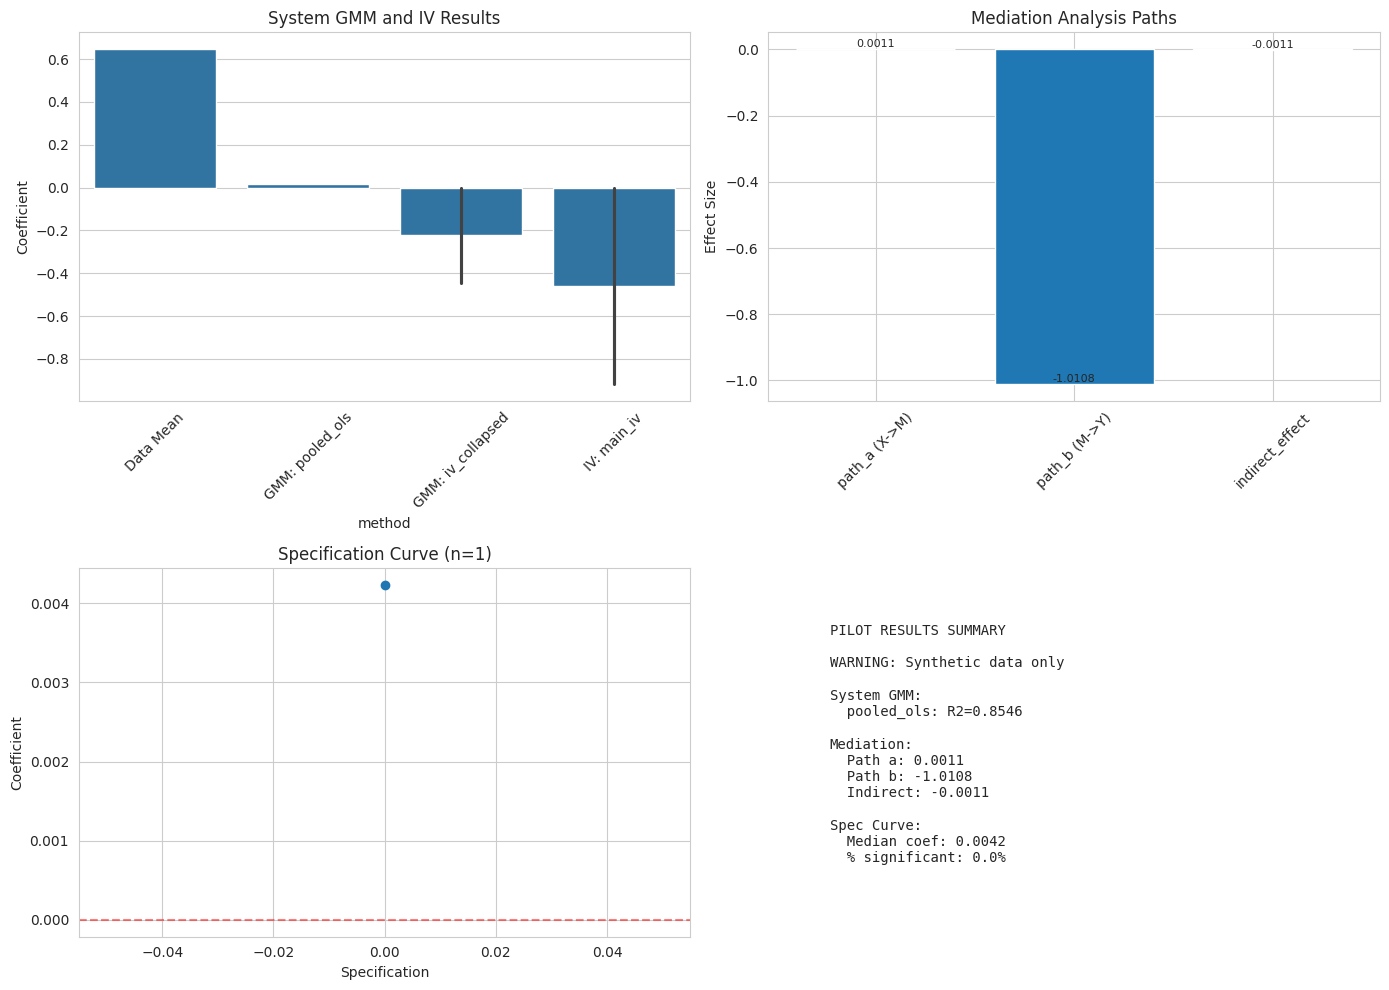


PILOT ANALYSIS COMPLETE
*** PILOT DATA - METHODOLOGY DEMONSTRATION ONLY - NOT FOR PUBLICATION ***


In [12]:
PILOT_DISCLAIMER = "*** PILOT DATA - METHODOLOGY DEMONSTRATION ONLY - NOT FOR PUBLICATION ***"

# Visualization of Results
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: System GMM and IV Coefficients
ax1 = axes[0, 0]

coefs_to_plot = []
coefs_to_plot.append({'method': 'Data Mean', 'coef': df['dem_resilience'].mean()})

if 'specifications' in system_gmm_results:
    for spec_name, spec_result in system_gmm_results['specifications'].items():
        if 'coefficients' in spec_result:
            for var, coef in spec_result['coefficients'].items():
                if var != 'constant':
                    coefs_to_plot.append({'method': f'GMM: {spec_name}', 'coef': coef})

if 'specifications' in iv_results:
    for spec_name, spec_result in iv_results['specifications'].items():
        if 'coefficients' in spec_result:
            for var, coef in spec_result['coefficients'].items():
                if var != 'constant':
                    coefs_to_plot.append({'method': f'IV: {spec_name}', 'coef': coef})

if len(coefs_to_plot) > 0:
    df_coefs = pd.DataFrame(coefs_to_plot)
    sns.barplot(data=df_coefs, x='method', y='coef', ax=ax1)
    ax1.set_title('System GMM and IV Results')
    ax1.set_ylabel('Coefficient')
    ax1.tick_params(axis='x', rotation=45)
else:
    ax1.text(0.5, 0.5, 'No coefficient data available', ha='center', va='center')
    ax1.set_title('System GMM and IV Coefficients (No Data)')

# Plot 2: Mediation Paths
ax2 = axes[0, 1]

if 'paths' in mediation_results:
    paths = mediation_results['paths']
    path_names = ['path_a (X->M)', 'path_b (M->Y)', 'indirect_effect']
    path_values = [paths.get('path_a', 0), paths.get('path_b', 0), paths.get('indirect_effect', 0)]
    
    bars = ax2.bar(path_names, path_values)
    ax2.set_title('Mediation Analysis Paths')
    ax2.set_ylabel('Effect Size')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar, val in zip(bars, path_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
else:
    ax2.text(0.5, 0.5, 'No mediation data available', ha='center', va='center')
    ax2.set_title('Mediation Analysis Paths (No Data)')

# Plot 3: Specification Curve
ax3 = axes[1, 0]

if 'results' in spec_curve_results:
    coefs = [r['coefficient'] for r in spec_curve_results['results']]
    ax3.plot(range(len(coefs)), coefs, marker='o')
    ax3.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax3.set_title(f'Specification Curve (n={len(coefs)})')
    ax3.set_xlabel('Specification')
    ax3.set_ylabel('Coefficient')
else:
    ax3.text(0.5, 0.5, 'No spec curve data available', ha='center', va='center')
    ax3.set_title('Specification Curve (No Data)')

# Plot 4: Summary Table
ax4 = axes[1, 1]
ax4.axis('off')

summary_text = "PILOT RESULTS SUMMARY\n\n"
summary_text += "WARNING: Synthetic data only\n\n"

if 'specifications' in system_gmm_results:
    summary_text += "System GMM:\n"
    for spec_name, spec_result in system_gmm_results['specifications'].items():
        if 'r_squared' in spec_result:
            summary_text += f"  {spec_name}: R2={spec_result['r_squared']:.4f}\n"

if 'paths' in mediation_results:
    summary_text += "\nMediation:\n"
    summary_text += f"  Path a: {mediation_results['paths'].get('path_a', 'N/A'):.4f}\n"
    summary_text += f"  Path b: {mediation_results['paths'].get('path_b', 'N/A'):.4f}\n"
    summary_text += f"  Indirect: {mediation_results['paths'].get('indirect_effect', 'N/A'):.4f}\n"

if 'proportion_significant' in spec_curve_results:
    summary_text += f"\nSpec Curve:\n"
    summary_text += f"  Median coef: {spec_curve_results.get('median_coefficient', 'N/A'):.4f}\n"
    summary_text += f"  % significant: {spec_curve_results.get('proportion_significant', 'N/A'):.1%}\n"

ax4.text(0.1, 0.5, summary_text, fontsize=10, family='monospace', va='center')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("PILOT ANALYSIS COMPLETE")
print("="*60)
print(PILOT_DISCLAIMER)


